<a href="https://colab.research.google.com/github/mikakia/AdvanceML_Final_Project/blob/main/blasto_ss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import os
import torch
from torch import nn
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import random_split, DataLoader

# Data Loading and EDA

## Before running:
Change shortcut to data.

For Ieva: 'content/drive/MyDrive/Data'

For Mika: '/content/drive/MyDrive/Advanced_ML/Final_Project/Data' <- It should work for both :)


## Load Data from google drive

In [14]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Change before running
ROOT_DIR = '/content/drive/MyDrive/Data'

blast_dir = os.path.join(ROOT_DIR, 'Blastocyst')
icm_dir = os.path.join(ROOT_DIR, 'GT_ICM')
te_dir = os.path.join(ROOT_DIR, 'GT_TE')
zp_dir = os.path.join(ROOT_DIR, 'GT_ZP')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
print(os.listdir('/content/drive/MyDrive/Data'))
#print(os.listdir('/content/drive/MyDrive/Advanced_ML'))

['Blast_PCRM_R13-0006A.BMP', 'Blast_PCRM_R13-0008B.BMP', 'Blast_PCRM_R13-0009A.BMP', 'Blast_PCRM_R13-0009B.BMP', 'Blast_PCRM_R13-0014A.BMP', 'Blast_PCRM_R13-0026.BMP', 'Blast_PCRM_R13-0022.BMP', 'Blast_PCRM_R13-0036B.BMP', 'Blast_PCRM_R13-0051A.BMP', 'Blast_PCRM_R13-0044.BMP', 'Blast_PCRM_R13-0052B.BMP', 'Blast_PCRM_R13-0058B.BMP', 'Blast_PCRM_R13-0057A.BMP', 'Blast_PCRM_R13-0065A.BMP', 'Blast_PCRM_R13-0065B.BMP', 'Blast_PCRM_R13-0073A.BMP', 'Blast_PCRM_R13-0077A.BMP', 'Blast_PCRM_R13-0077B.BMP', 'Blast_PCRM_R13-0074B.BMP', 'Blast_PCRM_R13-0081A.BMP', 'Blast_PCRM_R13-0081B.BMP', 'Blast_PCRM_2 x 2AB d5 left.BMP', 'Blast_PCRM_d5.2 left.BMP', 'Blast_PCRM_d5.2 right.BMP', 'Blast_PCRM_1202041 D5.BMP', 'Blast_PCRM_1202043 D5.BMP', 'Blast_PCRM_1202183 D5.BMP', 'Blast_PCRM_1202184 D5.BMP', 'Blast_PCRM_1202182 D5.BMP', 'Blast_PCRM_1202695 D5.BMP', 'Blast_PCRM_1202832 D6.BMP', 'Blast_PCRM_1202833 D5.BMP', 'Blast_PCRM_1202834 D5.BMP', 'Blast_PCRM_1202835 D6.BMP', 'Blast_PCRM_R14-0069a.BMP', 'Blas

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

## Creating a class for the data extending Dataset superclass

In [75]:

# Method to combine the masks into one
def masks_to_semantic(mask_list, background_label: int = 0):
  w, h = mask_list[0].shape
  semantic_mask = torch.full((h, w), fill_value=background_label, dtype=torch.int64)

  for class_idx, mask in enumerate(mask_list, start=1):
      semantic_mask[mask > 0] = class_idx

  return semantic_mask

# Creating Dataset class for our data
class BlastDataset(Dataset):
  MASK_NAMES = [' ICM', ' ZP', ' TE']

  def __init__(self, blast_dir, mask_dirs, size=(256, 256)):
    self.size = size
    self.image_transform = transforms.Compose([
        transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.ToTensor()
    ])
    self.mask_transform = transforms.Compose([
        transforms.Resize(size, interpolation=transforms.InterpolationMode.NEAREST)
    ])
    self.blast_dir = blast_dir
    self.mask_dirs = mask_dirs

    # Create masterlist of Blastocyst names
    self.filenames = sorted([
        f for f in os.listdir(blast_dir) if f.endswith('.BMP')
    ])



  # Returns number of images
  def __len__(self):
    return len(self.filenames)

  # Takes a blastocyst name and returns corresponding mask filename
  def _get_mask_name(self, blast_filename, mask_name):
    stem = os.path.splitext(blast_filename)[0] # Retrieves only image name
    return f"{stem}{mask_name}_Mask.bmp"

  # Fetch one sample
  def __getitem__(self, index):
    fname = self.filenames[index]
    image = self.image_transform(Image.open(os.path.join(self.blast_dir, fname)).convert('L'))

    masks = []
    for mask_name, mask_dir in zip(self.MASK_NAMES, self.mask_dirs):
      mask_fname = self._get_mask_name(fname, mask_name)
      mask = self.mask_transform(Image.open(os.path.join(mask_dir,mask_fname)).convert('L')) # Convert mask to grayscale
      masks.append(mask)

    # Convert to tensors here before passing to masks_to_semantic
    masks = [torch.from_numpy(np.array(m)).long() for m in masks]

    semantic_mask = masks_to_semantic(masks)

    return image, masks, semantic_mask

## Explore the Data

### Check for missing values

In [79]:
# Checking if any masks are missing
dataset = BlastDataset(
    blast_dir=blast_dir,
    mask_dirs=[icm_dir, zp_dir, te_dir]
)

missing = []
for fname in dataset.filenames:
  for mask_name, mask_dir in zip(dataset.MASK_NAMES, dataset.mask_dirs):
    mask_fname = dataset._get_mask_name(fname, mask_name)
    full_path = os.path.join(mask_dir, mask_fname)
    if not os.path.exists(full_path):
      missing.append(full_path)

print(missing)

[]


### Visualizations

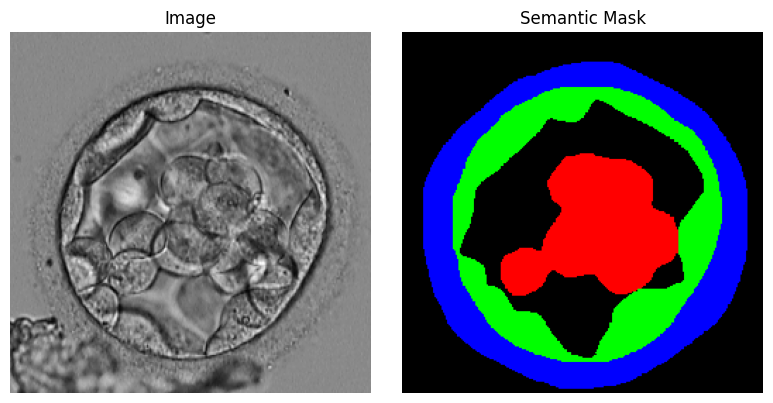

In [80]:
def semantic_mask_to_rgb(semantic_mask):
    # Define your color map: index = class label, value = (R, G, B)
    color_map = np.array([
        [0,   0,   0  ],  # 0 - background (black)
        [255, 0,   0  ],  # 1 - red
        [0,   0,   255],  # 2 - blue
        [0,   255, 0  ],  # 3 - green
    ], dtype=np.uint8)

    if hasattr(semantic_mask, "numpy"):
        semantic_mask = semantic_mask.numpy()

    return color_map[semantic_mask]  # (H, W) → (H, W, 3)


image, masks, semantic_mask = dataset[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image.squeeze(), cmap='grey')
axes[0].set_title('Image')

#for i, (mask, mask_name) in enumerate(zip(masks, [' ICM', ' ZP', ' TE'])):
#  axes[i+1].imshow(mask, cmap='gray')
#  axes[i+1].set_title(f'{mask_name} Mask')

axes[1].imshow(semantic_mask_to_rgb(semantic_mask))
axes[1].set_title('Semantic Mask')
for ax in axes:
  ax.axis('off')

plt.tight_layout()
plt.show()

### Check size

In [77]:
print("Image size:", image.shape)
print("ICM mask size:", masks[0].shape)
print("ZP mask size:", masks[1].shape)
print("TE mask size:", masks[2].shape)

Image size: torch.Size([1, 256, 256])
ICM mask size: torch.Size([256, 256])
ZP mask size: torch.Size([256, 256])
TE mask size: torch.Size([256, 256])


In [78]:
sizes = set()

for i in range(len(dataset)):
    image, masks, semantic_mask = dataset[i]
    sizes.add(image.shape)

if len(sizes) == 1:
    print(f"All images are the same size: {sizes.pop()}")
else:
    print(f"Different sizes found: {sizes}")

All images are the same size: torch.Size([1, 256, 256])


## DataLoaders

UNet works best with square inputs whose dimensions are divisible by 32 (because of the pooling layers)

In [81]:
total = len(dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_set, val_set, test_set = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=8, shuffle=False)

print(f"Train images: {len(train_set)} | Val images: {len(val_set)} | Test images: {len(test_set)}")

Train images: 174 | Val images: 37 | Test images: 38


In [86]:
for images, masks, semantic_masks in train_loader:
    print(images.shape)

torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])
torch.Size([6, 1, 256, 256])
